In [ ]:
from google.colab import files

uploaded = files.upload()

Saving InsuranceData.csv to InsuranceData.csv


In [ ]:
import pandas as pd
import numpy as np

# Change this to the exact uploaded filename
file_name = "InsuranceData.csv"

# For a CSV file:
data = pd.read_csv(file_name)

# Show the first 5 records
data.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,PolicyNumber,CustomerID,Gender,Age,PolicyType,PolicyStartDate,PolicyEndDate,PremiumAmount,CoverageAmount,ClaimNumber,ClaimDate,ClaimAmount,ClaimStatus
0,P1,C1,Female,73,Auto,13-02-2024,13-02-2025,240.64,33175.10,C1,NaN,0.00,Rejected
1,P2,C2,Male,44,Travel,03-03-2024,03-03-2025,1059.73,85046.42,C2,22-06-2024,1493.06,Pending
2,P3,C3,Female,28,Travel,15-06-2024,15-06-2025,1019.59,68525.53,C3,NaN,0.00,Rejected
3,P4,C4,Male,85,Travel,03-06-2024,03-06-2025,549.70,17053.27,C4,25-02-2025,5021.34,Pending
4,P5,C5,Female,57,Travel,13-06-2024,13-06-2025,841.15,55007.27,C5,30-11-2024,1347.46,Pending


In [ ]:
data = pd.read_csv("InsuranceData.csv")


In [ ]:
print(data.columns.tolist())

['PolicyNumber', 'CustomerID', 'Gender', 'Age', 'PolicyType', 'PolicyStartDate', 'PolicyEndDate', 'PremiumAmount', 'CoverageAmount', 'ClaimNumber', 'ClaimDate', 'ClaimAmount', 'ClaimStatus']


In [ ]:

data = data.dropna(subset=["ClaimStatus"]).copy()

feature_columns = [
    "Age",
    "Gender",
    "PolicyType",
    "CoverageAmount",
    "PremiumAmount",
    "active / inactive"
]

feature_columns = [column for column in feature_columns if column in data.columns]

X = data[feature_columns].copy()

y = data["ClaimStatus"].copy()

print("Features used:", feature_columns)
print(y.value_counts())

Features used: ['Age', 'Gender', 'PolicyType', 'CoverageAmount', 'PremiumAmount']
ClaimStatus
Rejected    4355
Settled     3386
Pending     2263
Name: count, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("number", numeric_transformer, numeric_features),
    ("text", categorical_transformer, categorical_features)
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("random_forest", rf_model)
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'CoverageAmount',
                                                   'PremiumAmount']),
                                                 ('text',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'PolicyType'])])),
                ('random_forest',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

              precision    recall  f1-score   support

     Pending       0.21      0.11      0.14       453
    Rejected       0.45      0.58      0.51       871
     Settled       0.34      0.32      0.33       677

    accuracy                           0.39      2001
   macro avg       0.33      0.34      0.33      2001
weighted avg       0.36      0.39      0.37      2001



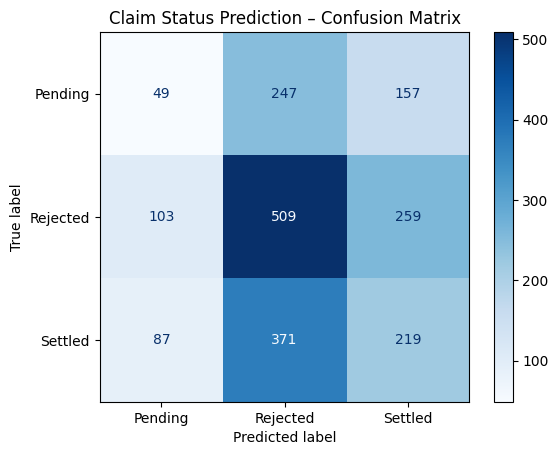

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Claim Status Prediction – Confusion Matrix")
plt.show()

In [ ]:
probabilities = model.predict_proba(X_test)

classes = model.named_steps["random_forest"].classes_
rejected_index = list(classes).index("Rejected")

id_columns = ["PolicyNumber", "CustomerID", "ClaimNumber"]
available_ids = [column for column in id_columns if column in data.columns]

results = data.loc[X_test.index, available_ids].copy()

results["Actual_ClaimStatus"] = y_test
results["Predicted_ClaimStatus"] = y_pred
results["Rejected_Probability"] = probabilities[:, rejected_index]

results["Risk_Level"] = np.where(
    results["Rejected_Probability"] >= 0.70, "High",
    np.where(results["Rejected_Probability"] >= 0.40, "Medium", "Low")
)

results.head()

,PolicyNumber,CustomerID,ClaimNumber,Actual_ClaimStatus,Predicted_ClaimStatus,Rejected_Probability,Risk_Level
8723,P8724,C8724,C8724,Settled,Rejected,0.513333,Medium
9894,P9895,C9895,C9895,Pending,Settled,0.230000,Low
9570,P9571,C9571,C9571,Settled,Rejected,0.450000,Medium
1931,P1932,C1932,C1932,Settled,Settled,0.326667,Low
928,P929,C929,C929,Pending,Pending,0.260000,Low


In [ ]:
results.to_csv("insurance_claim_predictions.csv", index=False)

from google.colab import files
files.download("insurance_claim_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>